In [154]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [155]:
import os

dataset_path = "/content/drive/MyDrive/GM-DATASET"

print(os.listdir(dataset_path))

['user_ratedmovies.dat', 'movies.dat', 'movie_genres.dat']


In [156]:
#Read(rows,columns).
import pandas as pd

ratings_path = dataset_path + "/user_ratedmovies.dat"
movies_path = dataset_path + "/movies.dat"
genres_path = dataset_path + "/movie_genres.dat"

ratings = pd.read_csv(ratings_path, sep="\t", encoding="latin-1")
movies = pd.read_csv(movies_path, sep="\t", encoding="latin-1")
genres = pd.read_csv(genres_path, sep="\t", encoding="latin-1")

print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)
print("Genres shape:", genres.shape)

Ratings shape: (855598, 9)
Movies shape: (10197, 21)
Genres shape: (20809, 2)


In [157]:
#inspecting actual structure of three datasets before processing.
print("RATINGS")
display(ratings.head())

print("\nRATINGS COLUMNS")
print(ratings.columns.tolist())

print("\nMOVIES")
display(movies.head())

print("\nMOVIES COLUMNS")
print(movies.columns.tolist())

print("\nGENRES")
display(genres.head())

print("\nGENRES COLUMNS")
print(genres.columns.tolist())

RATINGS


,userID,movieID,rating,date_day,date_month,date_year,date_hour,date_minute,date_second
0,75,3,1.0,29,10,2006,23,17,16
1,75,32,4.5,29,10,2006,23,23,44
2,75,110,4.0,29,10,2006,23,30,8
3,75,160,2.0,29,10,2006,23,16,52
4,75,163,4.0,29,10,2006,23,29,30



RATINGS COLUMNS
['userID', 'movieID', 'rating', 'date_day', 'date_month', 'date_year', 'date_hour', 'date_minute', 'date_second']

MOVIES


,id,title,imdbID,spanishTitle,imdbPictureURL,year,rtID,rtAllCriticsRating,rtAllCriticsNumReviews,rtAllCriticsNumFresh,...,rtAllCriticsScore,rtTopCriticsRating,rtTopCriticsNumReviews,rtTopCriticsNumFresh,rtTopCriticsNumRotten,rtTopCriticsScore,rtAudienceRating,rtAudienceNumRatings,rtAudienceScore,rtPictureURL
0,1,Toy story,114709,Toy story (juguetes),http://ia.media-imdb.com/images/M/MV5BMTMwNDU0...,1995,toy_story,9,73,73,...,100,8.5,17,17,0,100,3.7,102338,81,http://content7.flixster.com/movie/10/93/63/10...
1,2,Jumanji,113497,Jumanji,http://ia.media-imdb.com/images/M/MV5BMzM5NjE1...,1995,1068044-jumanji,5.6,28,13,...,46,5.8,5,2,3,40,3.2,44587,61,http://content8.flixster.com/movie/56/79/73/56...
2,3,Grumpy Old Men,107050,Dos viejos gruñones,http://ia.media-imdb.com/images/M/MV5BMTI5MTgy...,1993,grumpy_old_men,5.9,36,24,...,66,7,6,5,1,83,3.2,10489,66,http://content6.flixster.com/movie/25/60/25602...
3,4,Waiting to Exhale,114885,Esperando un respiro,http://ia.media-imdb.com/images/M/MV5BMTczMTMy...,1995,waiting_to_exhale,5.6,25,14,...,56,5.5,11,5,6,45,3.3,5666,79,http://content9.flixster.com/movie/10/94/17/10...
4,5,Father of the Bride Part II,113041,Vuelve el padre de la novia (Ahora también abu...,http://ia.media-imdb.com/images/M/MV5BMTg1NDc2...,1995,father_of_the_bride_part_ii,5.3,19,9,...,47,5.4,5,1,4,20,3,13761,64,http://content8.flixster.com/movie/25/54/25542...



MOVIES COLUMNS
['id', 'title', 'imdbID', 'spanishTitle', 'imdbPictureURL', 'year', 'rtID', 'rtAllCriticsRating', 'rtAllCriticsNumReviews', 'rtAllCriticsNumFresh', 'rtAllCriticsNumRotten', 'rtAllCriticsScore', 'rtTopCriticsRating', 'rtTopCriticsNumReviews', 'rtTopCriticsNumFresh', 'rtTopCriticsNumRotten', 'rtTopCriticsScore', 'rtAudienceRating', 'rtAudienceNumRatings', 'rtAudienceScore', 'rtPictureURL']

GENRES


,movieID,genre
0,1,Adventure
1,1,Animation
2,1,Children
3,1,Comedy
4,1,Fantasy



GENRES COLUMNS
['movieID', 'genre']


In [158]:
# We only need userID, movieID, rating from user_ratedmovies.dat, date/time columns aren't required.
# Keep ID, title, year from movies.dat, rename ID to movieID.
# Keep movieID, genre from movie_genres.dat, no unnecessary fields to remove.

In [159]:
#clean working DataFrames, rename ID-> movieID.
ratings_clean = ratings[['userID', 'movieID', 'rating']].copy()

movies_clean = movies[['id', 'title', 'year']].copy()
movies_clean = movies_clean.rename(columns={'id': 'movieID'})

genres_clean = genres[['movieID', 'genre']].copy()

print("Ratings:")
display(ratings_clean.head())

print("\nMovies:")
display(movies_clean.head())

print("\nGenres:")
display(genres_clean.head())

Ratings:


,userID,movieID,rating
0,75,3,1.0
1,75,32,4.5
2,75,110,4.0
3,75,160,2.0
4,75,163,4.0



Movies:


,movieID,title,year
0,1,Toy story,1995
1,2,Jumanji,1995
2,3,Grumpy Old Men,1993
3,4,Waiting to Exhale,1995
4,5,Father of the Bride Part II,1995



Genres:


,movieID,genre
0,1,Adventure
1,1,Animation
2,1,Children
3,1,Comedy
4,1,Fantasy


In [160]:
#check missing values, duplicate rating, if rating range(0.5-5.0), Movie ID consistency, dataset size.
print("Missing values:")
print("Ratings:", ratings_clean.isnull().sum().sum())
print("Movies:", movies_clean.isnull().sum().sum())
print("Genres:", genres_clean.isnull().sum().sum())

print("\nDuplicate user-movie ratings:")
print(ratings_clean.duplicated(subset=['userID', 'movieID']).sum())

print("\nRating range:")
print("Minimum:", ratings_clean['rating'].min())
print("Maximum:", ratings_clean['rating'].max())

print("\nMovie ID consistency:")
print("Ratings movies not in movies:", (~ratings_clean['movieID'].isin(movies_clean['movieID'])).sum())
print("Genres movies not in movies:", (~genres_clean['movieID'].isin(movies_clean['movieID'])).sum())

print("\nUnique counts:")
print("Users:", ratings_clean['userID'].nunique())
print("Movies:", movies_clean['movieID'].nunique())
print("Rated movies:", ratings_clean['movieID'].nunique())
print("Genres:", genres_clean['genre'].nunique())

Missing values:
Ratings: 0
Movies: 0
Genres: 0

Duplicate user-movie ratings:
0

Rating range:
Minimum: 0.5
Maximum: 5.0

Movie ID consistency:
Ratings movies not in movies: 0
Genres movies not in movies: 0

Unique counts:
Users: 2113
Movies: 10197
Rated movies: 10109
Genres: 20


In [161]:
# No missing values in any of the three datasets.
# No duplicate user–movie ratings.
# Ratings are valid: 0.5 to 5.0.
# All movie IDs in ratings and genres exist in the movies dataset.

In [162]:
#Calculate Movie-Genre edge weights (1 / number of genres of that movie), 20,809 movie–genre relationships
genre_counts = genres_clean.groupby('movieID')['genre'].count()

genres_clean['weight'] = genres_clean['movieID'].map(genre_counts).rdiv(1)

display(genres_clean.head(10))

,movieID,genre,weight
0,1,Adventure,0.200000
1,1,Animation,0.200000
2,1,Children,0.200000
3,1,Comedy,0.200000
4,1,Fantasy,0.200000
5,2,Adventure,0.333333
6,2,Children,0.333333
7,2,Fantasy,0.333333
8,3,Comedy,0.500000
9,3,Romance,0.500000


In [163]:
# Calculate User–Movie edge weights (rating / 5), 855,598 total ratings
ratings_clean['weight'] = ratings_clean['rating'] / 5

display(ratings_clean.head(10))

,userID,movieID,rating,weight
0,75,3,1.0,0.2
1,75,32,4.5,0.9
2,75,110,4.0,0.8
3,75,160,2.0,0.4
4,75,163,4.0,0.8
5,75,165,4.5,0.9
6,75,173,3.5,0.7
7,75,296,5.0,1.0
8,75,353,3.5,0.7
9,75,420,2.0,0.4


In [ ]:
#convert ID's to INT.
ratings_clean['userID'] = ratings_clean['userID'].astype(int)
ratings_clean['movieID'] = ratings_clean['movieID'].astype(int)
movies_clean['movieID'] = movies_clean['movieID'].astype(int)
genres_clean['movieID'] = genres_clean['movieID'].astype(int)

In [165]:
G = nx.Graph()
print("empty graph created")

empty graph created


In [166]:
# create user node, movie node and genre node for every unique user, movie, genre.
# Add User nodes
for user_id in ratings_clean['userID'].unique():
    G.add_node(f"U_{int(user_id)}", type="user")

# Add Movie nodes
for _, row in movies_clean.iterrows():
    G.add_node(
        f"M_{int(row['movieID'])}",
        type="movie",
        title=row['title'],
        year=row['year']
    )

# Add Genre nodes
for genre in genres_clean['genre'].unique():
    G.add_node(f"G_{genre}", type="genre")

print("User nodes:", sum(1 for _, d in G.nodes(data=True) if d['type'] == 'user'))
print("Movie nodes:", sum(1 for _, d in G.nodes(data=True) if d['type'] == 'movie'))
print("Genre nodes:", sum(1 for _, d in G.nodes(data=True) if d['type'] == 'genre'))
print("Total nodes:", G.number_of_nodes())

User nodes: 2113
Movie nodes: 10197
Genre nodes: 20
Total nodes: 12330


In [167]:
# add the User–Movie edges to graph.
for _, row in ratings_clean.iterrows():
    G.add_edge(
        f"U_{int(row['userID'])}",
        f"M_{int(row['movieID'])}",
        weight=row['weight'],
        relationship="rating"
    )

print("Rating edges:", sum(
    1 for _, _, d in G.edges(data=True)
    if d['relationship'] == 'rating'
))


Rating edges: 855598


In [168]:
# Movie–Genre edges
for _, row in genres_clean.iterrows():
    G.add_edge(
        f"M_{int(row['movieID'])}",
        f"G_{row['genre']}",
        weight=row['weight'],
        relationship="genre"
    )

print("Genre edges:", sum(
    1 for _, _, d in G.edges(data=True)
    if d['relationship'] == 'genre'
))

Genre edges: 20809


In [169]:
#verification
print("Graph summary")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

print("\nNode types:")
print("Users:", sum(1 for _, d in G.nodes(data=True) if d['type'] == 'user'))
print("Movies:", sum(1 for _, d in G.nodes(data=True) if d['type'] == 'movie'))
print("Genres:", sum(1 for _, d in G.nodes(data=True) if d['type'] == 'genre'))

print("\nEdge types:")
print("Rating edges:", sum(
    1 for _, _, d in G.edges(data=True)
    if d['relationship'] == 'rating'
))
print("Genre edges:", sum(
    1 for _, _, d in G.edges(data=True)
    if d['relationship'] == 'genre'
))

Graph summary
Nodes: 12330
Edges: 876407

Node types:
Users: 2113
Movies: 10197
Genres: 20

Edge types:
Rating edges: 855598
Genre edges: 20809


In [170]:
#node degree [12,330 nodes]
degrees = dict(G.degree())

print("Total nodes with degree:", len(degrees))
print("Sample node degrees:")

for node in list(degrees.keys())[:10]:
    print(node, "->", degrees[node])

Total nodes with degree: 12330
Sample node degrees:
U_75 -> 55
U_78 -> 468
U_127 -> 33
U_170 -> 83
U_175 -> 276
U_190 -> 296
U_267 -> 432
U_325 -> 273
U_383 -> 115
U_476 -> 356


In [171]:
# calculate average degree
user_degrees = [
    degrees[node]
    for node in G.nodes
    if G.nodes[node]["type"] == "user"
]

movie_degrees = [
    degrees[node]
    for node in G.nodes
    if G.nodes[node]["type"] == "movie"
]

genre_degrees = [
    degrees[node]
    for node in G.nodes
    if G.nodes[node]["type"] == "genre"
]

print("Average degree:")
print("Users:", sum(user_degrees) / len(user_degrees))
print("Movies:", sum(movie_degrees) / len(movie_degrees))
print("Genres:", sum(genre_degrees) / len(genre_degrees))

Average degree:
Users: 404.92096545196404
Movies: 85.94753358831029
Genres: 1040.45


In [172]:
#map title to movie.
id_to_title = dict(zip(movies_clean['movieID'], movies_clean['title']))

print("Movie title mapping created:", len(id_to_title))

Movie title mapping created: 10197


In [173]:
# Find movies with the highest degree

movie_degrees = {
    node: degree
    for node, degree in degrees.items()
    if G.nodes[node]["type"] == "movie"
}

top_movies = sorted(
    movie_degrees.items(),
    key=lambda x: x[1],
    reverse=True
)[:5]

print("Top 5 most connected movies:")

for node, degree in top_movies:
    movie_id = int(node.split("_")[1])
    title = id_to_title[movie_id]
    print(movie_id, "->", title, "->", degree, "connections")

Top 5 most connected movies:
2571 -> The Matrix -> 1673 connections
4993 -> The Lord of the Rings: The Fellowship of the Ring -> 1579 connections
356 -> Forrest Gump -> 1572 connections
296 -> Pulp Fiction -> 1540 connections
5952 -> The Lord of the Rings: The Two Towers -> 1531 connections


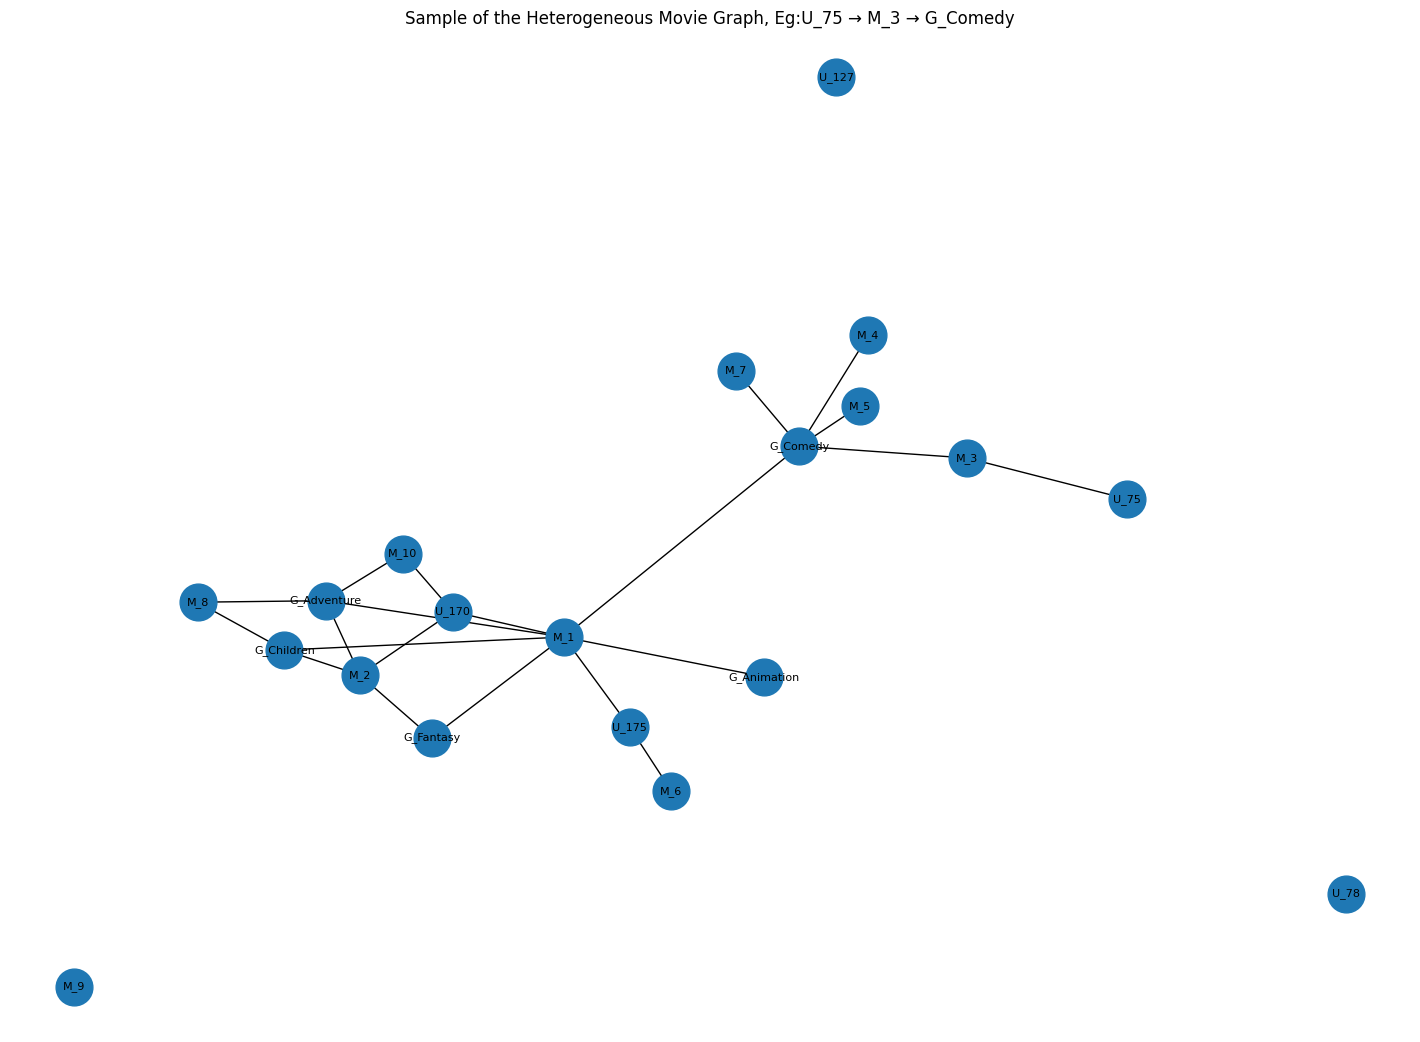

In [174]:
#small sample graph visualization
import matplotlib.pyplot as plt

users = [n for n in G.nodes if G.nodes[n]["type"] == "user"][:5]
movies_sample = [n for n in G.nodes if G.nodes[n]["type"] == "movie"][:10]
genres_sample = [n for n in G.nodes if G.nodes[n]["type"] == "genre"][:5]

sample_nodes = users + movies_sample + genres_sample
sample_graph = G.subgraph(sample_nodes)

plt.figure(figsize=(14, 10))

pos = nx.spring_layout(sample_graph, seed=42)

nx.draw(
    sample_graph,
    pos,
    with_labels=True,
    node_size=700,
    font_size=8
)

plt.title("Sample of the Heterogeneous Movie Graph, Eg:U_75 → M_3 → G_Comedy")
plt.show()

In [175]:
#target-user selection showing movies User 75 rated. (Sample)
target_user = 75

user_ratings = ratings_clean[
    ratings_clean['userID'] == target_user
].sort_values('rating', ascending=False)

print("Target User:", target_user)
print("Number of movies rated:", len(user_ratings))

display(user_ratings.head(10))

Target User: 75
Number of movies rated: 55


,userID,movieID,rating,weight
7,75,296,5.0,1.0
50,75,32587,5.0,1.0
5,75,165,4.5,0.9
17,75,1215,4.5,0.9
14,75,996,4.5,0.9
12,75,832,4.5,0.9
1,75,32,4.5,0.9
32,75,2700,4.5,0.9
54,75,45722,4.5,0.9
47,75,7007,4.5,0.9


In [176]:
#Personalized PageRank will start from a User and use the weighted relationships to propagate importance through the graph.

In [177]:
#map User-75 rated movies to their title, year and genres,
user_preferences = user_ratings.merge(
    movies_clean[['movieID', 'title', 'year']],
    on='movieID',
    how='left'
)

user_preferences = user_preferences.merge(
    genres_clean[['movieID', 'genre']],
    on='movieID',
    how='left'
)

display(user_preferences.head(15))

,userID,movieID,rating,weight,title,year,genre
0,75,296,5.0,1.0,Pulp Fiction,1994,Comedy
1,75,296,5.0,1.0,Pulp Fiction,1994,Crime
2,75,296,5.0,1.0,Pulp Fiction,1994,Drama
3,75,32587,5.0,1.0,Sin City,2005,Action
4,75,32587,5.0,1.0,Sin City,2005,Crime
5,75,32587,5.0,1.0,Sin City,2005,Film-Noir
6,75,32587,5.0,1.0,Sin City,2005,Thriller
7,75,165,4.5,0.9,Die Hard: With a Vengeance,1995,Action
8,75,165,4.5,0.9,Die Hard: With a Vengeance,1995,Crime
9,75,165,4.5,0.9,Die Hard: With a Vengeance,1995,Thriller


In [178]:
#PageRank for User-75 and inspecting the scores
personalization = {node: 0 for node in G.nodes}
personalization["U_75"] = 1

pagerank_scores = nx.pagerank(
    G,
    alpha=0.85,
    personalization=personalization,
    weight="weight"
)

print("PageRank calculated successfully.")
print("Total scores:", len(pagerank_scores))
print("Score for User 75:", pagerank_scores["U_75"])

PageRank calculated successfully.
Total scores: 12330
Score for User 75: 0.15041550764324882


In [179]:
#take the Personalized PageRank scores we calculated and finds which movie nodes have the highest scores for User-75.
movie_scores = {
    node: score
    for node, score in pagerank_scores.items()
    if G.nodes[node]["type"] == "movie"
}

top_movies_pagerank = sorted(
    movie_scores.items(),
    key=lambda x: x[1],
    reverse=True
)

print("Total movie scores:", len(movie_scores))
print("\nTop 10 movies by Personalized PageRank:")

for node, score in top_movies_pagerank[:10]:
    movie_id = int(node.split("_")[1])
    title = id_to_title[movie_id]
    print(movie_id, "->", title, "->", score)

Total movie scores: 10197

Top 10 movies by Personalized PageRank:
296 -> Pulp Fiction -> 0.004133518609583211
32587 -> Sin City -> 0.003869422111811438
2571 -> The Matrix -> 0.0038634263868126744
2959 -> Fight Club -> 0.003753014383837094
32 -> Twelve Monkeys -> 0.0035770860122055935
1527 -> The Fifth Element -> 0.003521707426797355
165 -> Die Hard: With a Vengeance -> 0.0033602034160177233
2700 -> South Park: Bigger Longer & Uncut -> 0.0033415353132650264
45722 -> Pirates of the Caribbean: Dead Man's Chest -> 0.0033248103312940045
589 -> Terminator 2: Judgment Day -> 0.0032774905715859566


In [180]:
# filter out 55 already-rated movies by user-75.
rated_movie_ids = set(user_ratings['movieID'])

recommendations = [
    (node, score)
    for node, score in top_movies_pagerank
    if int(node.split("_")[1]) not in rated_movie_ids
]

print("Top 10 recommended movies:")

for node, score in recommendations[:10]:
    movie_id = int(node.split("_")[1])
    title = id_to_title[movie_id]
    print(movie_id, "->", title, "->", score)

Top 10 recommended movies:
318 -> The Shawshank Redemption -> 0.0007461631134395721
356 -> Forrest Gump -> 0.0007323210292235191
2858 -> American Beauty -> 0.000706856100902406
593 -> The Silence of the Lambs -> 0.0006860756572067843
260 -> Star Wars -> 0.0006665201989125124
4226 -> Memento -> 0.0006476995921752022
1196 -> Star Wars: Episode V - The Empire Strikes Back -> 0.0006417741441553989
1198 -> Raiders of the Lost Ark -> 0.000637879951926448
4306 -> Shrek -> 0.0006329197382505972
1270 -> Back to the Future -> 0.0006311498636979431


In [181]:
#For User 75, Personalized PageRank recommended these 10 movies that the user has not already rated.
#For User 75, The Shawshank Redemption has the highest Personalized PageRank score among the movies that User 75 has not already rated.

User 75 connections: 55
Sample connections: ['M_3', 'M_32', 'M_110', 'M_160', 'M_163', 'M_165', 'M_173', 'M_296', 'M_353', 'M_420']


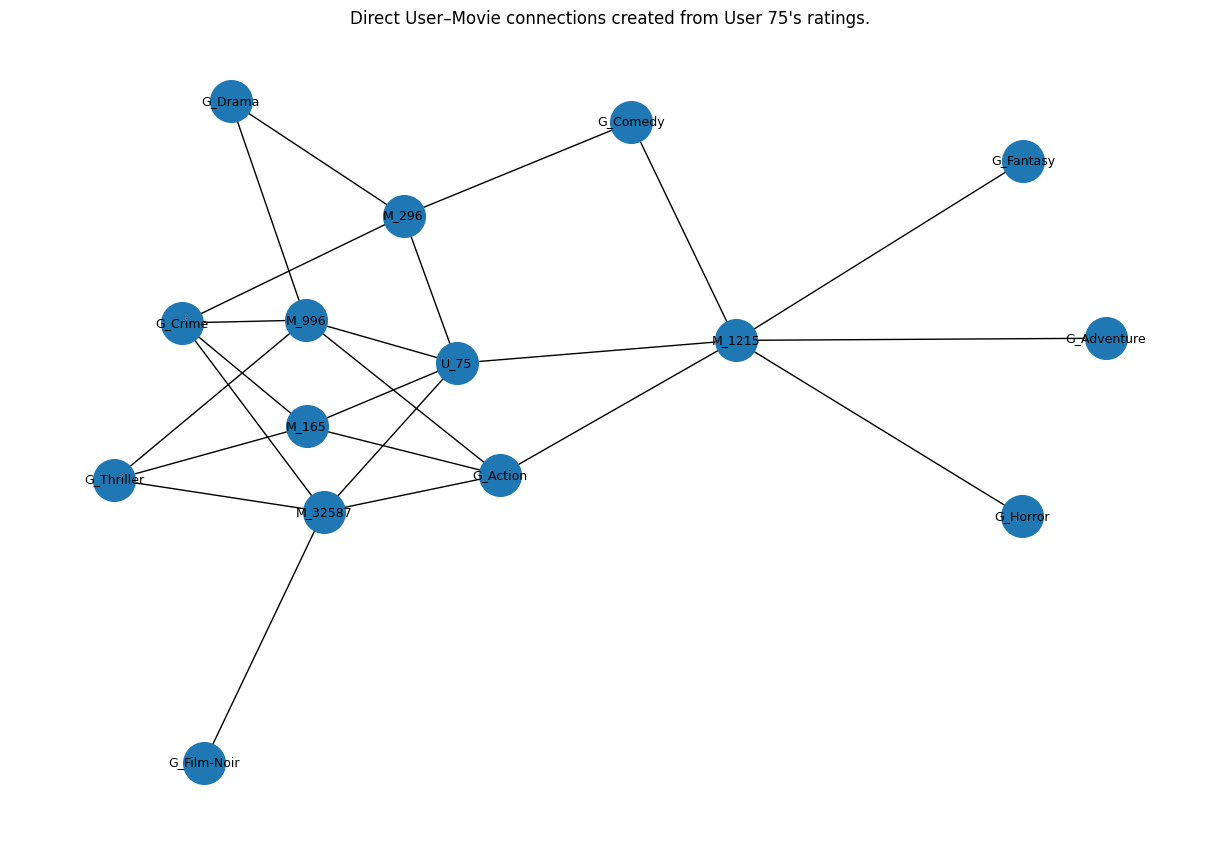

In [182]:
target_node = "U_75"

neighbors = list(G.neighbors(target_node))

print("User 75 connections:", len(neighbors))
print("Sample connections:", neighbors[:10])
top_rated_movies = user_ratings.head(5)['movieID'].tolist()

sample_nodes = {"U_75"}

for movie_id in top_rated_movies:
    movie_node = f"M_{int(movie_id)}"
    sample_nodes.add(movie_node)

    for neighbor in G.neighbors(movie_node):
        if G.nodes[neighbor]["type"] == "genre":
            sample_nodes.add(neighbor)

sample_graph = G.subgraph(sample_nodes)

plt.figure(figsize=(12, 8))

pos = nx.spring_layout(sample_graph, seed=42)

nx.draw(
    sample_graph,
    pos,
    with_labels=True,
    node_size=900,
    font_size=9
)

plt.title("Direct User–Movie connections created from User 75's ratings.")
plt.show()

In [183]:
# Find users with enough ratings for 80/20 train-test split for evaluation.
user_rating_counts = ratings_clean.groupby('userID').size()

eligible_users = user_rating_counts[
    user_rating_counts >= 50
]

print("Total users:", len(user_rating_counts))
print("Users with at least 50 ratings:", len(eligible_users))

print("\nSample eligible users:")
print(eligible_users.head(10))

Total users: 2113
Users with at least 50 ratings: 1872

Sample eligible users:
userID
75      55
78     468
170     83
175    276
190    296
267    432
325    273
383    115
476    356
477    131
dtype: int64


In [184]:
# Randomly select 20 reproducible users
evaluation_users = eligible_users.sample(
    n=20,
    random_state=42
).index.tolist()

print("Number of evaluation users:", len(evaluation_users))
print("Evaluation userID's:", evaluation_users)

Number of evaluation users: 20
Evaluation userID's: [65595, 47002, 56016, 11220, 16039, 39393, 10094, 14648, 12451, 8434, 33579, 39799, 50295, 13472, 59771, 21712, 51466, 18600, 39047, 44404]


In [185]:
# Create train/test data for these 20 users.
from sklearn.model_selection import train_test_split

multi_train = []
multi_test = []

for user_id in evaluation_users:
    user_data = ratings_clean[
        ratings_clean['userID'] == user_id
    ].copy()

    train_user, test_user = train_test_split(
        user_data,
        test_size=0.2,
        random_state=42
    )

    multi_train.append(train_user)
    multi_test.append(test_user)

multi_train = pd.concat(multi_train, ignore_index=True)
multi_test = pd.concat(multi_test, ignore_index=True)

print("Training ratings:", len(multi_train))
print("Test ratings:", len(multi_test))
print("Evaluation users:", multi_train['userID'].nunique())

Training ratings: 4378
Test ratings: 1107
Evaluation users: 20


In [186]:
G_eval = nx.Graph()

for user_id in multi_train['userID'].unique():
    G_eval.add_node(
        f"U_{int(user_id)}",
        type="user"
    )

for _, row in movies_clean.iterrows():
    G_eval.add_node(
        f"M_{int(row['movieID'])}",
        type="movie",
        title=row['title'],
        year=row['year']
    )

for genre in genres_clean['genre'].unique():
    G_eval.add_node(
        f"G_{genre}",
        type="genre"
    )

for _, row in multi_train.iterrows():
    G_eval.add_edge(
        f"U_{int(row['userID'])}",
        f"M_{int(row['movieID'])}",
        weight=row['rating'] / 5,
        relationship="rating"
    )

for _, row in genres_clean.iterrows():
    G_eval.add_edge(
        f"M_{int(row['movieID'])}",
        f"G_{row['genre']}",
        weight=row['weight'],
        relationship="genre"
    )

print("Evaluation graph created")
print("Nodes:", G_eval.number_of_nodes())
print("Edges:", G_eval.number_of_edges())

Evaluation graph created
Nodes: 10237
Edges: 25187


In [187]:
# Generate Top-5 recommendations for each user
multi_results = []

for user_id in evaluation_users:

    user_train = multi_train[
        multi_train['userID'] == user_id
    ]

    personalization = {
        node: 0
        for node in G_eval.nodes
    }

    for _, row in user_train.iterrows():
        movie_id = int(row['movieID'])
        personalization[f"M_{movie_id}"] = row['rating'] / 5

    pagerank_scores_user = nx.pagerank(
        G_eval,
        alpha=0.85,
        personalization=personalization,
        weight="weight"
    )

    movie_scores_user = {
        node: score
        for node, score in pagerank_scores_user.items()
        if G_eval.nodes[node]["type"] == "movie"
    }

    ranked_movies = sorted(
        movie_scores_user.items(),
        key=lambda x: x[1],
        reverse=True
    )

    train_movie_ids_user = set(
        user_train['movieID']
    )

    recommendations_user = [
        (node, score)
        for node, score in ranked_movies
        if int(node.split("_")[1]) not in train_movie_ids_user
    ][:5]

    for rank, (node, score) in enumerate(
        recommendations_user,
        start=1
    ):
        movie_id = int(node.split("_")[1])

        multi_results.append({
            'userID': user_id,
            'rank': rank,
            'movieID': movie_id,
            'score': score
        })

multi_results_df = pd.DataFrame(multi_results)

print("Recommendations generated successfully.")
print("Total recommendation records:", len(multi_results_df))

Recommendations generated successfully.
Total recommendation records: 100


In [188]:
#Convert the recommendations into a table
multi_results_df = pd.DataFrame(multi_results)

In [189]:
# Calculate Precision@5 across the 20 users
precisions_at_5 = []

for user_id in evaluation_users:

    recommended_ids = set(
        multi_results_df[
            (multi_results_df['userID'] == user_id) &
            (multi_results_df['rank'] <= 5)
        ]['movieID']
    )

    test_ids = set(
        multi_test[
            multi_test['userID'] == user_id
        ]['movieID']
    )

    hits = recommended_ids & test_ids

    precision_at_5 = len(hits) / 5
    precisions_at_5.append(precision_at_5)

average_precision_at_5 = sum(precisions_at_5) / len(precisions_at_5)

print("Users evaluated:", len(evaluation_users))
print("Average Precision@5:", average_precision_at_5)
print("Average Precision@5 (%):", average_precision_at_5 * 100)

Users evaluated: 20
Average Precision@5: 0.32
Average Precision@5 (%): 32.0


In [190]:
# Out of 2,113 users, 1,872 users had at least 50 ratings and were eligible for evaluation.
# We randomly selected 20 eligible users using a fixed random seed
# Across these 20 users, the Personalized PageRank recommender achieved a Precision@5 of 32%.

# For every user, we generated the top 5 movie recommendations and checked them against the movies hidden from that user during testing.
# On average(0.32 * 5), each user received average 1.6 relevant recommendations from hidden among their Top-5.

In [191]:
# BASELINE - We used a highly-rated popularity baseline.
# We first considered movies with an average training rating of 4.0 or above
# then ranked them by the number of ratings. This gives us a popularity baseline that considers both rating quality and popularity.

In [192]:
# Create the highly-rated popularity list
high_rated_movies = (
    multi_train
    .groupby('movieID')
    .agg(
        rating_count=('rating', 'count'),
        average_rating=('rating', 'mean')
    )
)

high_rated_movies = high_rated_movies[
    high_rated_movies['average_rating'] >= 4.0
]

high_rated_movies = high_rated_movies.sort_values(
    'rating_count',
    ascending=False
)

print("Top 10 highly-rated popular movies:")
print(high_rated_movies.head(10))

Top 10 highly-rated popular movies:
         rating_count  average_rating
movieID                              
356                16        4.156250
2571               16        4.031250
2959               15        4.366667
2028               14        4.178571
4886               14        4.035714
4306               13        4.115385
296                13        4.307692
4226               13        4.307692
8961               12        4.041667
3147               11        4.181818


In [193]:
# Generate Top-5 recommendations
high_rated_recommendations = []

high_rated_movie_ids = high_rated_movies.index.tolist()

for user_id in evaluation_users:

    user_train = multi_train[
        multi_train['userID'] == user_id
    ]

    rated_movie_ids = set(user_train['movieID'])

    recommendations = [
        movie_id
        for movie_id in high_rated_movie_ids
        if movie_id not in rated_movie_ids
    ][:5]

    for rank, movie_id in enumerate(recommendations, start=1):
        high_rated_recommendations.append({
            'userID': user_id,
            'rank': rank,
            'movieID': movie_id
        })

high_rated_results_df = pd.DataFrame(
    high_rated_recommendations
)

print("Users evaluated:", len(evaluation_users))
print("Recommendation records:", len(high_rated_results_df))

Users evaluated: 20
Recommendation records: 100


In [194]:
# Calculate Precision@5 FRO BASELINE
high_rated_precisions_at_5 = []

for user_id in evaluation_users:

    recommended_ids = set(
        high_rated_results_df[
            high_rated_results_df['userID'] == user_id
        ]['movieID']
    )

    test_ids = set(
        multi_test[
            multi_test['userID'] == user_id
        ]['movieID']
    )

    hits = recommended_ids & test_ids

    precision_at_5 = len(hits) / 5
    high_rated_precisions_at_5.append(precision_at_5)

average_high_rated_precision_at_5 = (
    sum(high_rated_precisions_at_5) /
    len(high_rated_precisions_at_5)
)

print(
    "Highly Rated Popularity Precision@5:",
    average_high_rated_precision_at_5
)

print(
    "Highly Rated Popularity Precision@5 (%):",
    average_high_rated_precision_at_5 * 100
)

Highly Rated Popularity Precision@5: 0.25
Highly Rated Popularity Precision@5 (%): 25.0


In [195]:
#Personalized PageRank: 32%
#Highly Rated Popularity: 25%

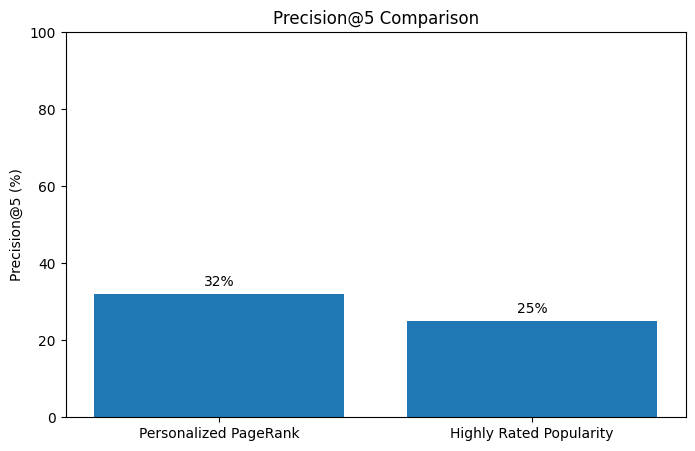

In [196]:
import matplotlib.pyplot as plt

methods = ['Personalized PageRank', 'Highly Rated Popularity']
precision = [32, 25]

plt.figure(figsize=(8, 5))
plt.bar(methods, precision)

plt.ylabel('Precision@5 (%)')
plt.title('Precision@5 Comparison')
plt.ylim(0, 100)

for i, value in enumerate(precision):
    plt.text(i, value + 2, f'{value}%', ha='center')

plt.show()

In [197]:
evaluation_summary = pd.DataFrame({
    'Evaluation Metric': [
        'Users Evaluated',
        'Recommendations per User',
        'Total Recommendation Slots',
        'Personalized PageRank Precision@5',
        'Highly Rated Popularity Precision@5'
    ],
    'Result': [
        20,
        5,
        100,
        '32%',
        '25%'
    ]
})

display(evaluation_summary)

,Evaluation Metric,Result
0,Users Evaluated,20
1,Recommendations per User,5
2,Total Recommendation Slots,100
3,Personalized PageRank Precision@5,32%
4,Highly Rated Popularity Precision@5,25%
